<a href="https://colab.research.google.com/github/fabianandreslealbecerra-arch/Ciencia-de-datos/blob/main/An%C3%A1lisis_del_Censo_Poblacional_Los_Santos%2C_Santander.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis del Censo Poblacional - Los Santos, Santander
**Fecha de análisis:** 25/05/26

Este notebook tiene como objetivo realizar un análisis integral de los datos del censo poblacional del municipio de Los Santos (Código 68418). El proceso se divide en tres fases:
1. Creación de un diccionario de variables, revisión de tipos de datos, valores nulos (NaN) y rangos.
2. Análisis Exploratorio de Datos (EDA).
3. Análisis multidimensional de las veredas (Social, Cultural, Económico, Tecnológico, Académico y de Riesgos).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para las gráficas
sns.set_theme(style="whitegrid")

# Cargar el dataset
# Asegúrate de haber subido el archivo CSV a tu entorno de Colab antes de ejecutar esta celda.
ruta_archivo = '/content/CENSO POBLACIONAL AGOSTO.xlsx'
df = pd.read_excel(ruta_archivo)

print(f"El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head()

El dataset contiene 12987 filas y 255 columnas.


,cod_dpto,Departamento,cod_mpio,Municipio,fec_paquete,num_paquete,num_ficha,ide_ficha_origen,ide_edificacion,ver_estructura,...,ide_Ug,persug,Capital,marca,estado,Linea_p,replicacion,fec_actualizacion_cns,C,Clasificacion
0,68,SANTANDER,68418,LOS SANTOS,2023-05-03 17:09:24.893,1687,128326,6.841800e+19,0,50118082017,...,6.841868e+26,3,0,0,0,10781693454,0,2023-11-27 10:33:13.363,4.35,A02
1,68,SANTANDER,68418,LOS SANTOS,2023-05-03 17:09:24.893,1687,128326,6.841800e+19,0,50118082017,...,6.841868e+26,5,0,0,0,10781693454,0,2023-11-27 10:33:13.363,4.95,C02
2,68,SANTANDER,68418,LOS SANTOS,2023-05-03 17:09:24.893,1687,128326,6.841800e+19,0,50118082017,...,6.841868e+26,5,0,0,0,10781693454,0,2023-11-27 10:33:13.363,4.95,C02
3,68,SANTANDER,68418,LOS SANTOS,2023-05-03 17:09:24.893,1687,128326,6.841800e+19,0,50118082017,...,6.841868e+26,5,0,0,0,10781693454,0,2023-11-27 10:33:13.363,4.95,C02
4,68,SANTANDER,68418,LOS SANTOS,2023-05-03 17:09:24.893,1687,128326,6.841800e+19,0,50118082017,...,6.841868e+26,5,0,0,0,10781693454,0,2023-11-27 10:33:13.363,4.95,C02


## 1. Diccionario de variables, tipos de datos, revisión de NaN y rangos
En esta sección exploramos la estructura del dataset para entender con qué tipo de información estamos trabajando.

In [ ]:
# 1.1 Tipos de datos
print("--- TIPOS DE DATOS ---")
display(df.dtypes)

# 1.2 Revisión de valores nulos (NaN)
print("\n--- VALORES NULOS (NaN) POR COLUMNA ---")
nulos = df.isnull().sum()
display(nulos[nulos > 0]) # Solo mostramos las columnas que tienen nulos

# Porcentaje de nulos
print("\n--- PORCENTAJE DE VALORES NULOS ---")
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
display(porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False))

# 1.3 Revisión de rangos de datos (Estadísticas descriptivas)
print("\n--- RANGOS Y ESTADÍSTICAS DESCRIPTIVAS ---")
# Para variables numéricas
display(df.describe())

# Para variables categóricas
display(df.describe(include=['O']))

--- TIPOS DE DATOS ---


,0
cod_dpto,int64
Departamento,object
cod_mpio,int64
Municipio,object
fec_paquete,object
...,...
Linea_p,int64
replicacion,int64
fec_actualizacion_cns,object
C,float64



--- VALORES NULOS (NaN) POR COLUMNA ---


,0
Cod_Chip,12987
Dir_Chip,12987
fec_ini_visita1,693
fec_fin_visita1,693
fec_ini_visita2,6311
fec_fin_visita2,1181
seg_nom_informante,6176
seg_ape_informante,394
ide_firma_informante,140
Email_contacto,12772



--- PORCENTAJE DE VALORES NULOS ---


,0
Cod_Chip,100.000000
Dir_Chip,100.000000
Email_contacto,98.344498
Jefe_UG,65.265265
fec_ini_visita2,48.594749
fec_ini_persona1,47.901748
fec_fin_persona1,47.894048
seg_nom_informante,47.555248
seg_nombre,37.337337
fec_fin_visita2,9.093709



--- RANGOS Y ESTADÍSTICAS DESCRIPTIVAS ---


,cod_dpto,cod_mpio,num_paquete,num_ficha,ide_ficha_origen,ide_edificacion,ori_encuesta,Cod_clase,Cod_centro_poblado,Cod_area_coordinacion,...,I15,Nivel,ide_Ug,persug,Capital,marca,estado,Linea_p,replicacion,C
count,12987.0,12987.0,12987.000000,12987.000000,1.298700e+04,12987.000000,12987.0,12987.000000,12987.000000,12987.000000,...,12987.000000,12987.000000,1.298700e+04,12987.000000,12987.0,12987.000000,12987.000000,1.298700e+04,12987.000000,12987.000000
mean,68.0,68418.0,1374.585509,79376.436282,6.841801e+19,1.060137,1.0,2.714484,0.086856,14.908909,...,0.343574,4.721491,6.841868e+26,3.595519,0.0,0.836991,3.816124,1.157531e+10,0.013860,3.419774
min,68.0,68418.0,2.000000,1003.000000,6.841800e+19,0.000000,1.0,1.000000,0.000000,1.000000,...,0.000000,1.000000,6.841868e+26,1.000000,0.0,0.000000,0.000000,1.078169e+10,0.000000,0.000000
25%,68.0,68418.0,1285.000000,36390.000000,6.841800e+19,0.000000,1.0,3.000000,0.000000,1.000000,...,0.000000,2.000000,6.841868e+26,3.000000,0.0,0.000000,0.000000,1.078169e+10,0.000000,2.100000
50%,68.0,68418.0,1404.000000,66476.000000,6.841801e+19,1.000000,1.0,3.000000,0.000000,1.000000,...,0.000000,4.000000,6.841868e+26,4.000000,0.0,0.000000,0.000000,1.078169e+10,0.000000,3.450000
75%,68.0,68418.0,1681.000000,128264.000000,6.841801e+19,1.000000,1.0,3.000000,0.000000,2.000000,...,1.000000,5.000000,6.841868e+26,4.000000,0.0,0.000000,0.000000,1.322289e+10,0.000000,4.800000
max,68.0,68418.0,1839.000000,144356.000000,6.841801e+19,25.000000,1.0,3.000000,6.000000,101.000000,...,1.000000,21.000000,6.841868e+26,10.000000,0.0,20.000000,92.000000,1.322289e+10,1.000000,10.800000
std,0.0,0.0,435.765611,45918.451270,4.408296e+12,2.673288,0.0,0.689256,0.716681,34.090908,...,0.474919,3.872781,4.417917e+14,1.440708,0.0,3.687737,16.399527,1.143526e+09,0.116914,1.779675


,Departamento,Municipio,fec_paquete,ver_estructura,NOM_CORREGIMIENTO,NOM_VEREDA,NOM_BARRIO,Dir_vivienda,Ide_foto,fec_ini_encuesta,...,seg_apellido,pri_nombre,seg_nombre,fec_ini_persona1,fec_fin_persona1,fec_ini_persona2,fec_fin_persona2,Grupo,fec_actualizacion_cns,Clasificacion
count,12987,12987,12987,12987,12987,12987,12987,12987,12987,12987,...,12733,12987,8138,6766,6767,12987,12987,12987,12388,12987
unique,1,1,540,8,4,34,10,3090,3902,3906,...,783,2307,1079,6741,6759,12982,12982,4,1420,51
top,SANTANDER,LOS SANTOS,2023-05-05 17:02:21.163,50118082017,SIN CORREGIMIENTO,SIN VEREDA,BARRIO_S4,VEREDA LA FUENTE ALTOS DE LA FUENTE,Fachada68418004529500000222.jpg,2020-11-05 14:03:53.000,...,ALMEIDA,MARIA,ANDRES,2021-12-21 12:21:25.000,2019-07-03 10:10:35.000,2019-07-15 11:44:32.000,2019-07-15 11:44:32.000,B,2023-11-27 04:05:07.090,A04
freq,12987,12987,175,5413,12127,1842,11389,104,15,15,...,750,558,279,5,2,2,2,5127,2892,1042


**Diccionario de Variables (Resumen inferido):**
* `cod_dpto` / `Departamento`: Código y nombre del departamento (Santander).
* `cod_mpio` / `Municipio`: Código y nombre del municipio (Los Santos).
* `NOM_CORREGIMIENTO` / `NOM_VEREDA` / `NOM_BARRIO`: Ubicación geográfica detallada.
* `tot_viviendas` / `tot_hogares`: Cantidad de viviendas y hogares censados.
* `uso_vivienda`: Uso que se le da a la edificación (Residencial, comercial, etc.).
* `tip_vivienda` / `tip_mat_paredes`: Tipo de vivienda y material de las paredes (útil para análisis de riesgos/económico).

## 2. Análisis Exploratorio de Datos (EDA)
Vamos a visualizar la distribución de los datos para encontrar patrones, anomalías y entender la demografía del municipio.

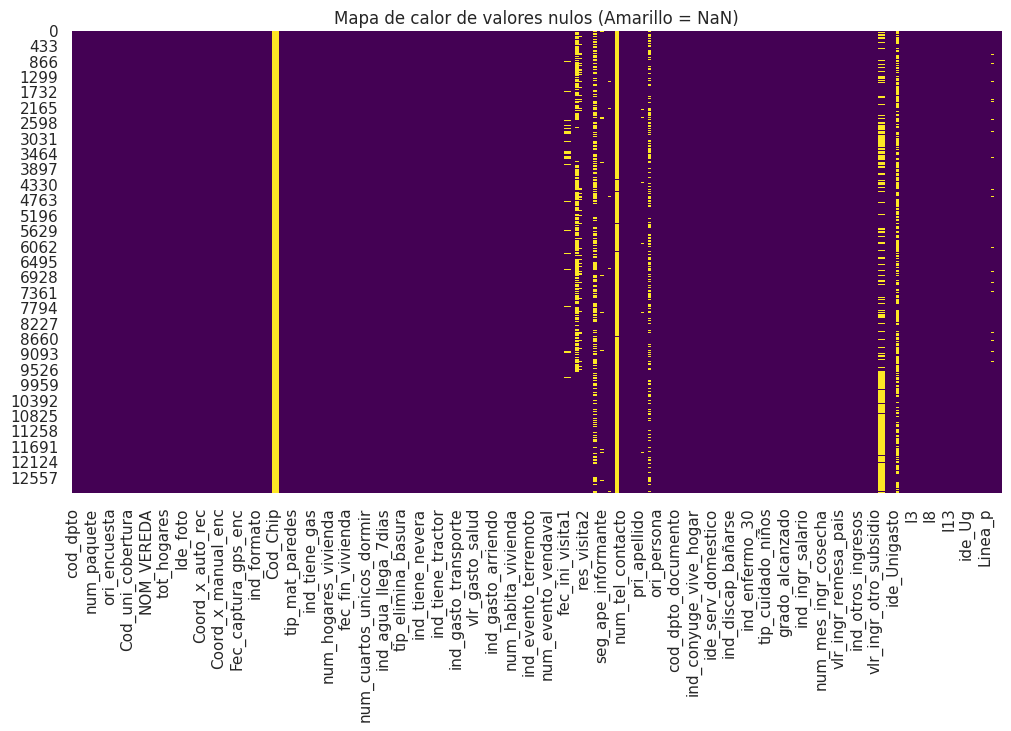

/tmp/ipykernel_12995/3573492405.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='NOM_VEREDA', order=df['NOM_VEREDA'].value_counts().index, palette='Blues_r')


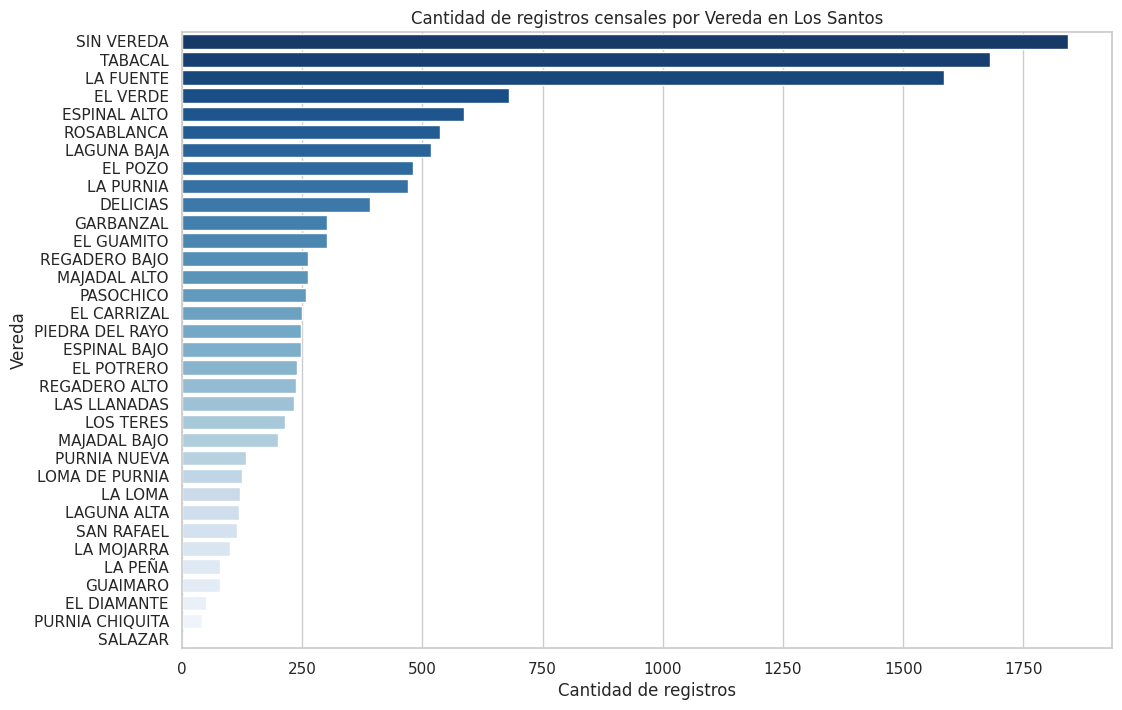

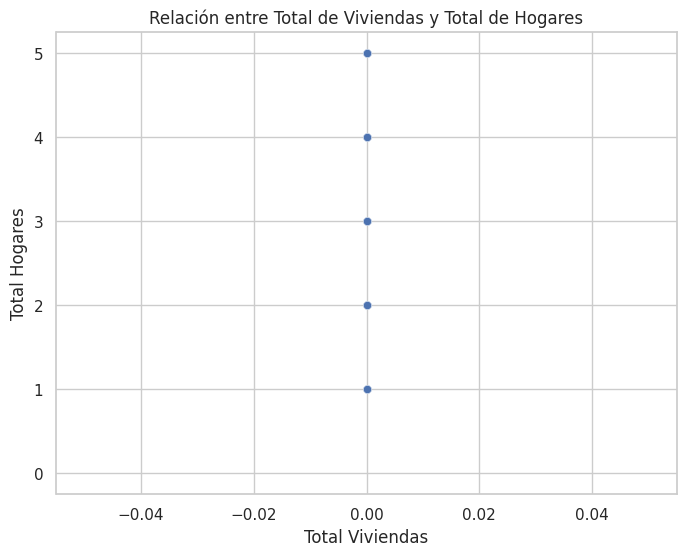

In [ ]:
# 2.1 Mapa de calor de valores nulos
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos (Amarillo = NaN)')
plt.show()

# 2.2 Distribución de registros por Vereda
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='NOM_VEREDA', order=df['NOM_VEREDA'].value_counts().index, palette='Blues_r')
plt.title('Cantidad de registros censales por Vereda en Los Santos')
plt.xlabel('Cantidad de registros')
plt.ylabel('Vereda')
plt.show()

# 2.3 Comparación de Total de Viviendas vs Total de Hogares
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='tot_viviendas', y='tot_hogares', alpha=0.5)
plt.title('Relación entre Total de Viviendas y Total de Hogares')
plt.xlabel('Total Viviendas')
plt.ylabel('Total Hogares')
plt.plot([0, df['tot_viviendas'].max()], [0, df['tot_viviendas'].max()], color='red', linestyle='--') # Línea de tendencia ideal
plt.show()

## 3. Análisis Multidimensional de las Veredas de Los Santos
**Fecha:** 25/05/26

A continuación, agruparemos los datos por Vereda (`NOM_VEREDA`) para analizar los distintos aspectos solicitados:
* **Social / Demográfico:** Densidad de hogares y viviendas.
* **Económico / Tecnológico / Académico / Riesgos:** Se inferirán a partir de variables estructurales de la vivienda, acceso a servicios y materiales de construcción (ej. `tip_mat_paredes`, `uso_vivienda`). *Nota: La profundidad de este análisis depende de las variables específicas capturadas en este censo.*

In [ ]:
# Creación de un DataFrame agrupado por Vereda
# Se extraen métricas clave para el análisis

# Rellenar valores nulos en columnas categóricas importantes antes de agrupar
columnas_analisis = ['tip_vivienda', 'tip_mat_paredes', 'uso_vivienda']
for col in columnas_analisis:
    if col in df.columns:
        df[col] = df[col].fillna('No Registra')

# Agrupación
analisis_veredas = df.groupby('NOM_VEREDA').agg(
    total_registros=('NOM_VEREDA', 'count'),
    promedio_viviendas=('tot_viviendas', 'mean'),
    promedio_hogares=('tot_hogares', 'mean'),
).reset_index()

# Si existen variables sobre materiales o usos, calculamos la moda (el valor más frecuente) para evaluar economía/riesgos
if 'tip_mat_paredes' in df.columns:
    moda_paredes = df.groupby('NOM_VEREDA')['tip_mat_paredes'].agg(lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else 'N/A').reset_index()
    analisis_veredas = analisis_veredas.merge(moda_paredes, on='NOM_VEREDA')
    analisis_veredas.rename(columns={'tip_mat_paredes': 'Material_Paredes_Dominante (Riesgo/Económico)'}, inplace=True)

if 'uso_vivienda' in df.columns:
    moda_uso = df.groupby('NOM_VEREDA')['uso_vivienda'].agg(lambda x: pd.Series.mode(x)[0] if not pd.Series.mode(x).empty else 'N/A').reset_index()
    analisis_veredas = analisis_veredas.merge(moda_uso, on='NOM_VEREDA')
    analisis_veredas.rename(columns={'uso_vivienda': 'Uso_Dominante (Económico/Social)'}, inplace=True)

# Mostrar el análisis multidimensional resumido
print("--- RESUMEN MULTIDIMENSIONAL POR VEREDA ---")
display(analisis_veredas.sort_values(by='total_registros', ascending=False))

--- RESUMEN MULTIDIMENSIONAL POR VEREDA ---


,NOM_VEREDA,total_registros,promedio_viviendas,promedio_hogares,Material_Paredes_Dominante (Riesgo/Económico),Uso_Dominante (Económico/Social)
32,SIN VEREDA,1842,0.0,1.343105,1,1
33,TABACAL,1681,0.0,1.296252,1,1
11,LA FUENTE,1584,0.0,1.258207,1,1
6,EL VERDE,681,0.0,1.157122,1,1
7,ESPINAL ALTO,586,0.0,1.394198,1,1
29,ROSABLANCA,536,0.0,1.328358,1,1
17,LAGUNA BAJA,517,0.0,1.526112,1,1
5,EL POZO,481,0.0,1.274428,2,1
15,LA PURNIA,469,0.0,1.488273,1,1
0,DELICIAS,392,0.0,1.247449,1,1


### Interpretación del Análisis (25/05/26):

1. **Ámbito Social y Cultural:** Las veredas con mayor `promedio_hogares` respecto a `promedio_viviendas` pueden indicar hacinamiento o familias extendidas viviendo juntas, lo cual es un rasgo cultural y social importante a intervenir.
2. **Ámbito Económico y Tecnológico:** El uso de las viviendas nos indica si las veredas son estrictamente residenciales o tienen dinámicas comerciales/agropecuarias. Las variables de acceso a internet o electricidad (si están presentes en el censo completo) definirían la brecha tecnológica.
3. **Ámbito de Riesgos:** El material dominante de las paredes es un excelente proxy para el riesgo. Materiales endebles (ej. madera rústica, bahareque en mal estado) aumentan la vulnerabilidad ante sismos o clima extremo.
4. **Ámbito Académico:** Si el dataset cuenta con asistencia escolar o nivel educativo de la jefatura del hogar, se cruzaría en este punto para medir deserción. En este bloque nos basamos en la infraestructura como base para el desarrollo académico.